# **Machine Learning Final Project**
Name: Teddy Fabrizio Baeny Vargas

Class: DAMO-640-8

Date: December 6th, 2025

Professor: William Pourmajidi

### **Assignment Description**
You will build and evaluate a feed-forward artificial neural network (ANN) for a multiclass classification problem using the UCI Seeds dataset. The dataset contains 210 samples, 7 numeric features, and 3 classes.




## **Section 1. Data Loading & EDA**

This first section involves loading the dataset and doing exploratory analysis to start understanding what it contains.

#### **Imported libraries**

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Fixed seed for reproducibility
tf.random.set_seed(42)

#### **Dataset loading**

In this part, I set the column names based on the url given in the assignment and show a sample of the first 5 rows of the dataset.

In [87]:
dataset = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"

column_names = [
    'area', 'perimeter','compactness','length_of_kernel',
    'width_of_kernel','asymmetry_coefficient',
    'length_of_kernel_groove','class'
]

# Data transformation using pandas
data = pd.read_csv(dataset, sep='\s+', header=None, names=column_names)

print(data.shape)
data.head()

(210, 8)


,area,perimeter,compactness,length_of_kernel,width_of_kernel,asymmetry_coefficient,length_of_kernel_groove,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


#### **Class Distribution**
This module shows the different classes of wheat based on the information given in the url of the dataset. As we can see, there is no imbalance in the classes as not one of them is overrepresented.

Class distribution:
class_name
Kama        70
Rosa        70
Canadian    70
Name: count, dtype: int64

In percentages:
class_name
Kama        33.333333
Rosa        33.333333
Canadian    33.333333
Name: proportion, dtype: float64


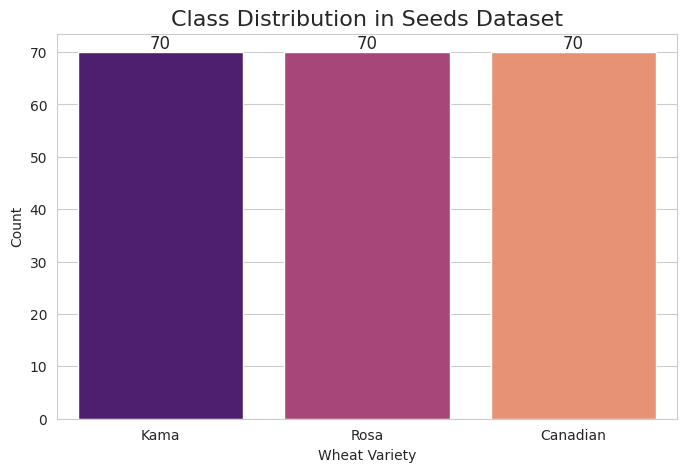

In [88]:
data['class'] = data['class'].astype(int)

# Class names
class_names = {1: 'Kama', 2: 'Rosa', 3: 'Canadian'}
data['class_name'] = data['class'].map(class_names)

print("Class distribution:")
print(data['class_name'].value_counts())
print("\nIn percentages:")
print(data['class_name'].value_counts(normalize=True) * 100)

# Distribution plot
plt.figure(figsize=(8,5))
ax = sns.countplot(x='class_name', data=data, order=['Kama','Rosa','Canadian'], palette='magma')
ax.set_title('Class Distribution in Seeds Dataset', fontsize=16)
ax.set_xlabel('Wheat Variety')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.show()

#### **Summary Statistics**
The next part of this section involves doing the summary statistics for the dataset. Besides doing this for all numerical columns, the features' mean was also calculated for the three classes in the dataset.

In [89]:
features = column_names[:-2]  # exclude class columns

print("Summary statistics (overall):")
display(data[features].describe())

print("\Mean by class:")
display(data.groupby('class_name')[features].mean().round(4))

Summary statistics (overall):


,area,perimeter,compactness,length_of_kernel,width_of_kernel,asymmetry_coefficient
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000


\Mean by class:


,area,perimeter,compactness,length_of_kernel,width_of_kernel,asymmetry_coefficient
class_name,,,,,,
Canadian,11.8739,13.2479,0.8494,5.2295,2.8538,4.7884
Kama,14.3344,14.2943,0.8801,5.5081,3.2446,2.6674
Rosa,18.3343,16.1357,0.8835,6.1480,3.6774,3.6448


#### **Feature Distribution**

This next part shows both a distribution histogram and boxplot of the different features while dividing it into the three classes for more detailed insights. These visualizations give the hint that the three classes have similar distributions, as well as very few outliers in the different features in the dataset.

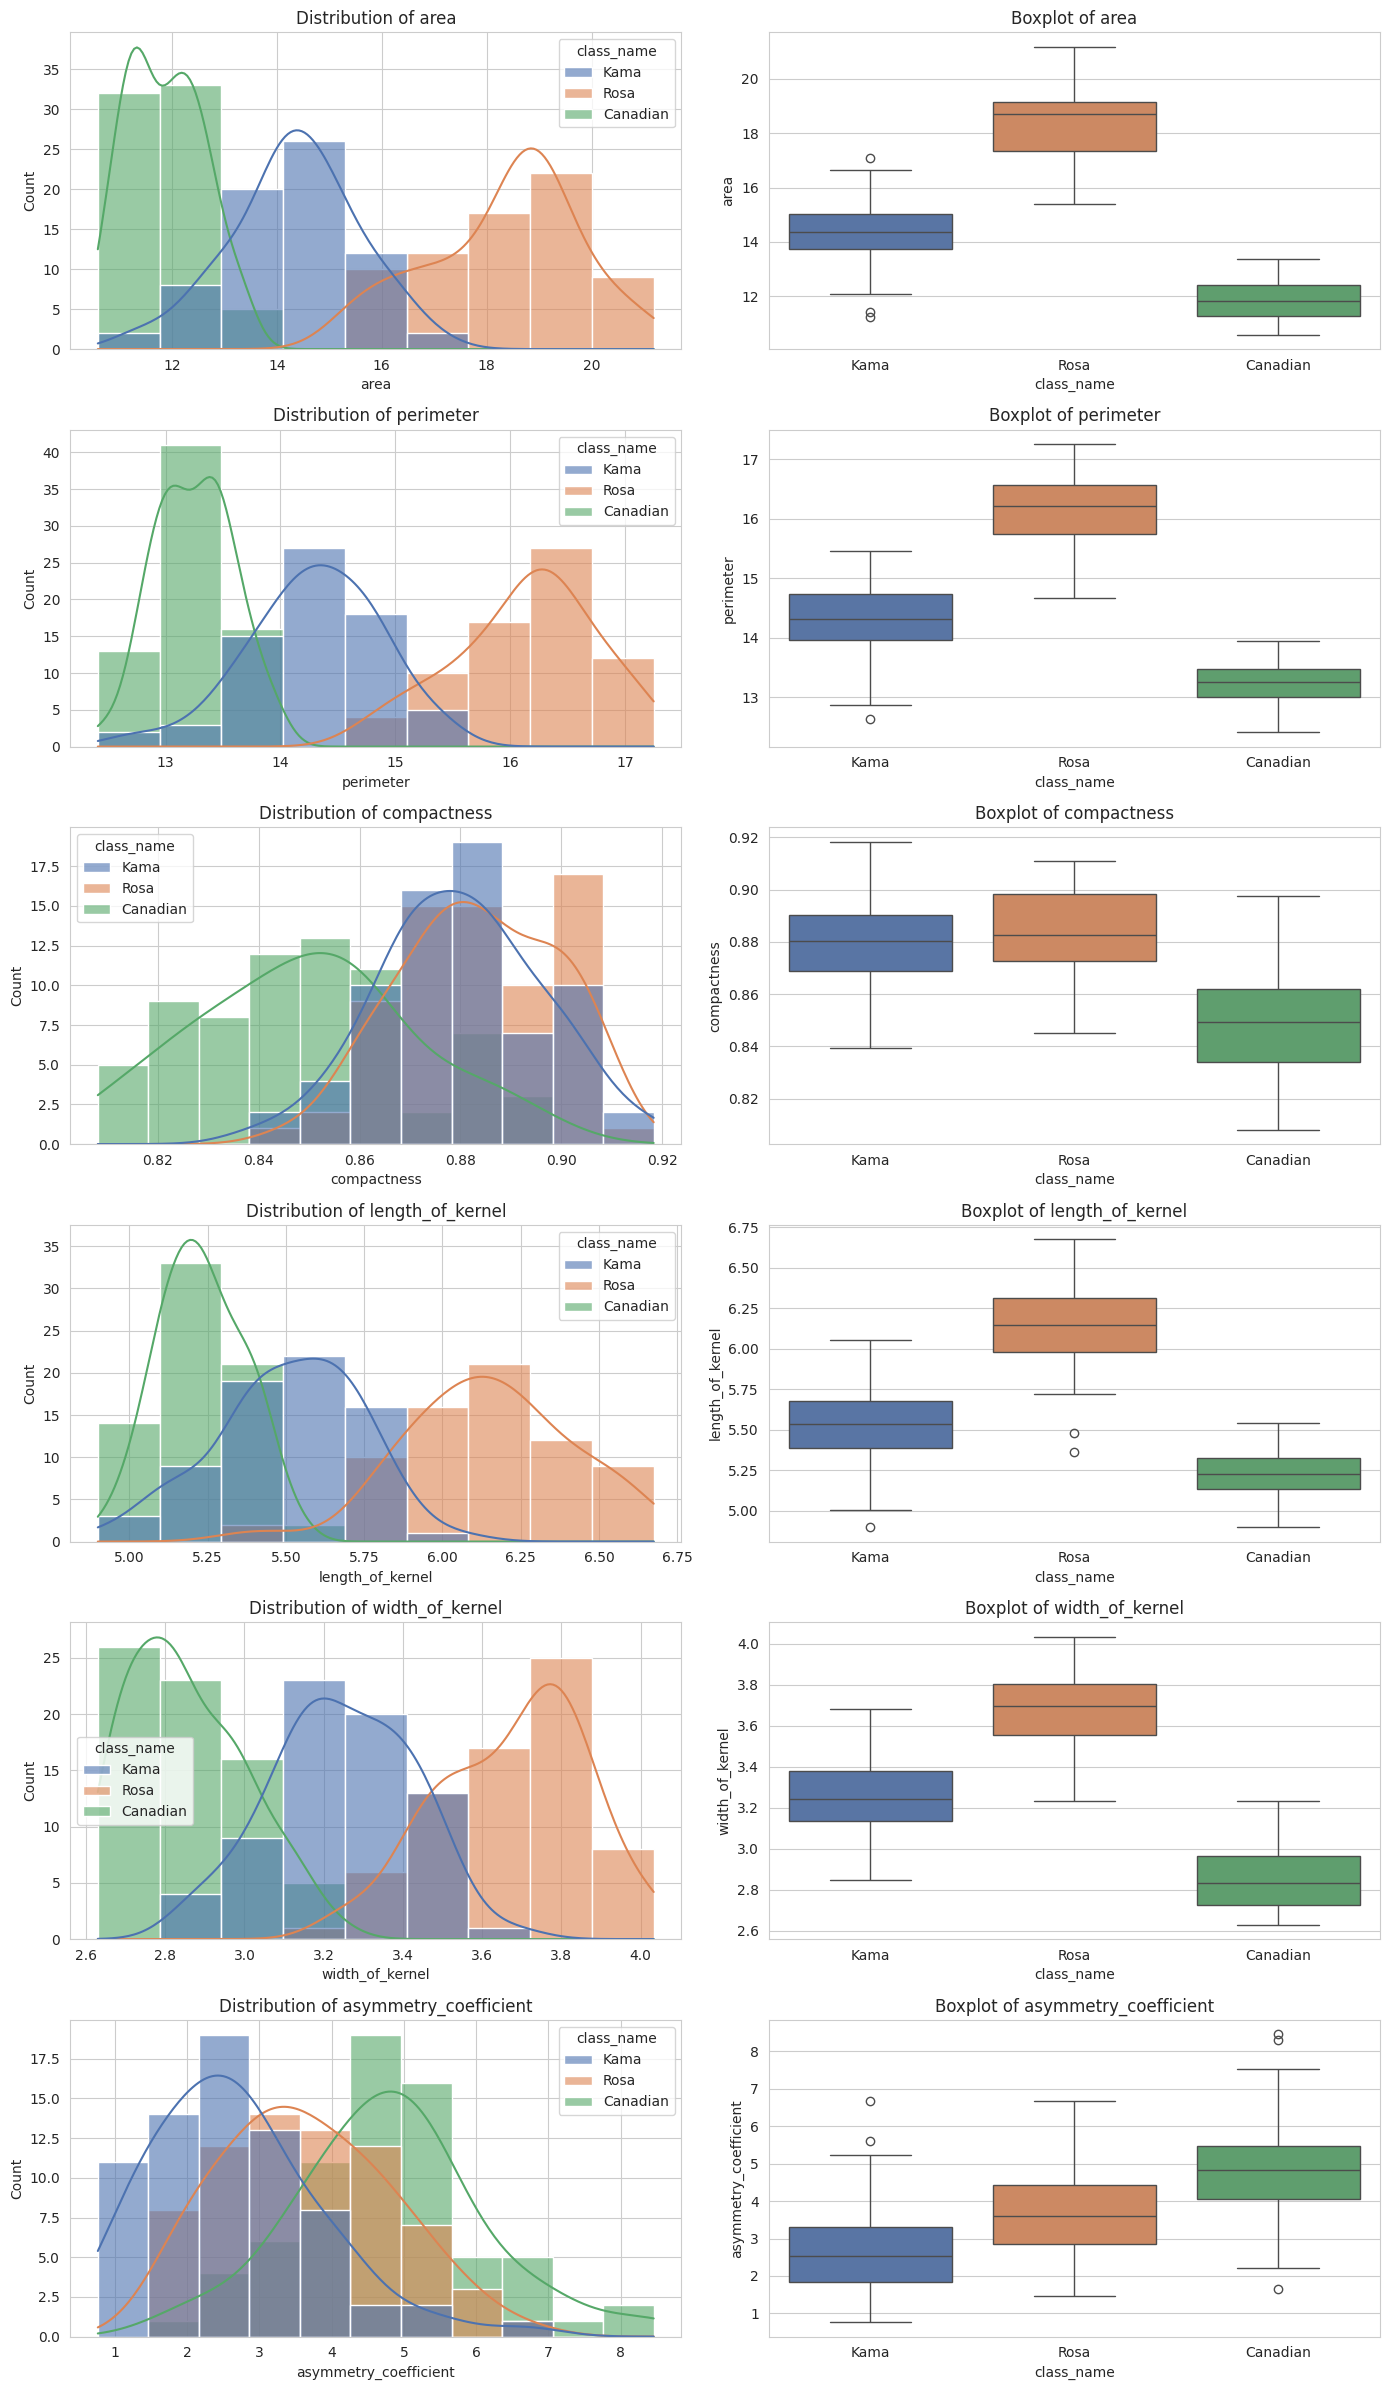

In [90]:
n_features = len(features)
fig, axes = plt.subplots(n_features, 2, figsize=(14, 4*n_features))

for i, feat in enumerate(features):
    # Histogram + KDE
    sns.histplot(data=data, x=feat, hue='class_name', kde=True, palette='deep', ax=axes[i,0], alpha=0.6)
    axes[i,0].set_title(f'Distribution of {feat}')

    # Boxplot
    sns.boxplot(x='class_name', y=feat, data=data, palette='deep', ax=axes[i,1])
    axes[i,1].set_title(f'Boxplot of {feat}')

plt.tight_layout()
plt.show()

#### **Correlation Heatmap**
The final graph for this section is a correlation heatmap that shows that all features have a high positive correlation among themselves, and only the asymmetry coefficient has a low negative correlation with the rest of the variables.

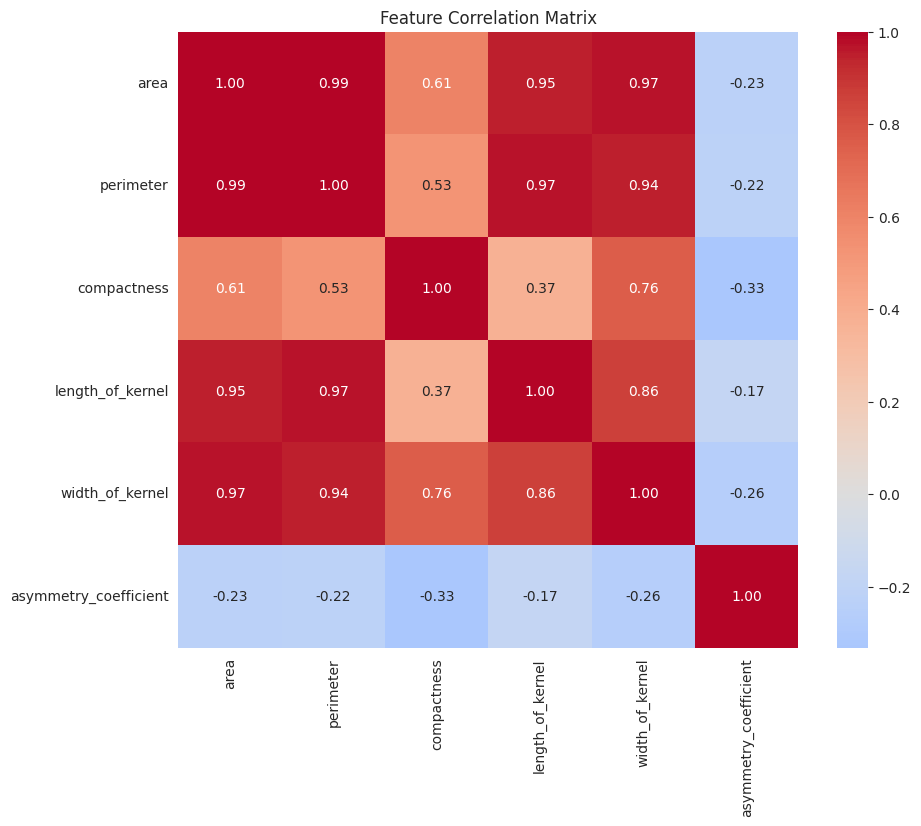

In [91]:

plt.figure(figsize=(10,8))
sns.heatmap(data[features].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

### **Conclusions for Section 1**
* There is moderate variability in the dataset given the low values in standard deviation.
* Rosa has the biggest values in mean for all the features and Canadian has the smallest ones, this coudl indicate that each class is different from each other.
* There is overlap in the class distributions for the different features, but the distributions do not looke very different from each other.
* There is high correlation values in all features which suggests feature redundancy.

## **Section 2. Preprocessing**

The second section consists of preprocessing the dataset using scaling and getting it ready for the ANN model.

#### **Missing Values and Feature/Target Division**
This first part includes looking for missing values in the dataset which are none for all features, and dividing the variables into two: Features (All numerical) and Target (Wheat Class).

In [92]:
# Missing Values for all Features
missing_values = data.isnull().sum()
print("Missing Values:")
print(missing_values)

# Features and target division
X = data.drop(['class', 'class_name'], axis=1)
y = data['class'] - 1

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nClass distribution in full dataset:")
print(y.value_counts().sort_index())

Missing Values:
area                       0
perimeter                  0
compactness                0
length_of_kernel           0
width_of_kernel            0
asymmetry_coefficient      0
length_of_kernel_groove    0
class                      0
class_name                 0
dtype: int64
Feature matrix shape: (210, 7)
Target vector shape: (210,)

Class distribution in full dataset:
class
0    70
1    70
2    70
Name: count, dtype: int64


#### **Train/Test Split**
In this module, a split in the dataset is make where 80% of the data is used for training and the remaining 20% is used for testing. It is important to stratify so all classes have similar representation in both training and test data.

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set    : {X_test.shape[0]} samples")
print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nClass distribution in test set:")
print(pd.Series(y_test).value_counts().sort_index())

Training set: 168 samples
Test set    : 42 samples

Class distribution in training set:
class
0    56
1    56
2    56
Name: count, dtype: int64

Class distribution in test set:
class
0    14
1    14
2    14
Name: count, dtype: int64


#### **Standard Scaling**
Finally, Standard Scaling is used to transform the data so the training and test data can be stable and efficient. This transformation is essential for neural networks given its sensitivity to different magnitude features.

In [94]:
# Feature scaling using StandardScaler
scaler = StandardScaler()

# Fit on training data only, then transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling completed!")
print(f"Training features mean after scaling: {X_train_scaled.mean(axis=0).round(10)}")
print(f"Training features std  after scaling: {X_train_scaled.std(axis=0).round(10)}")

Scaling completed!
Training features mean after scaling: [-0. -0.  0.  0. -0.  0.  0.]
Training features std  after scaling: [1. 1. 1. 1. 1. 1. 1.]


## **Conclusions for Section 2**
* There are no missing values in the dataset and stratification is essential to represent all classes equally.
* Stratification was made along train/test split for model building and evaluation as well as standard scaling for model preparation.

## **Section 3. ANN Design and Training**

#### **Model Building**
The model selected for this assignment is a multi-layer perceptron (MLP) using TensorFlow/Keras with the following architecture:

- Input layer: 7 features  
- Hidden layer 1: 64 units, ReLU, Dropout 0.4  
- Hidden layer 2: 32 units, ReLU, Dropout 0.4  
- Output layer: 3 units + softmax  

Optimizer: Adam (learning rate = 0.001)  
Loss: sparse_categorical_crossentropy (labels are 0, 1, 2 for the 3 wheat classes)  
Regularization: Dropout (chosen over L2 for its simplicity and strong performance on small datasets)  
Training: 100 epochs + EarlyStopping to avoid unnecessary computation

In [97]:
# Build the model
model = Sequential([
    Dense(64, activation='relu', input_shape=(7,)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_75 (Dense)                │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,691 (10.51 KB)

 Trainable params: 2,691 (10.51 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
# Early stopping to prevent overfitting while still giving enough epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model with the validation split
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.3685 - loss: 1.1247 - val_accuracy: 0.8235 - val_loss: 0.8971
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6591 - loss: 0.8812 - val_accuracy: 0.8824 - val_loss: 0.7215
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6799 - loss: 0.8310 - val_accuracy: 0.8529 - val_loss: 0.6060
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8151 - loss: 0.6809 - val_accuracy: 0.8529 - val_loss: 0.5235
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8254 - loss: 0.6488 - val_accuracy: 0.8529 - val_loss: 0.4593
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8263 - loss: 0.5583 - val_accuracy: 0.8529 - val_loss: 0.4077
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8368 - loss: 0.4912 - val_accuracy: 0.8824 - val_loss: 0.3698
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8426 - loss: 0.4982 - val_accuracy: 0.8824 - val_loss:

#### **Plot Training and Validation Accuracy and Loss**

The graphs below as well as the epoch results show the model's performance over epochs on both the training set (blue) and validation set (orange):

- **Left Plot: Accuracy Curves**  
The training accuracy started on a low value but increased quickly around the fifth epoch and it reaches a maximum accuracy value of 0.9760 in the last run epoch (71). The validation data has a similar pattern and stops increasing around epoch 60. This indicates good generalization and the model is avoiding overfitting.

- **Right Plot: Loss Curves**  
Training loss drops rapidly from ~1.1 to near 0 as the model gets confident. Validation loss mirrors this, bottoming out around the same point as peak val acc. EarlyStopping halted training when validation loss stopped improving after epoch 60.

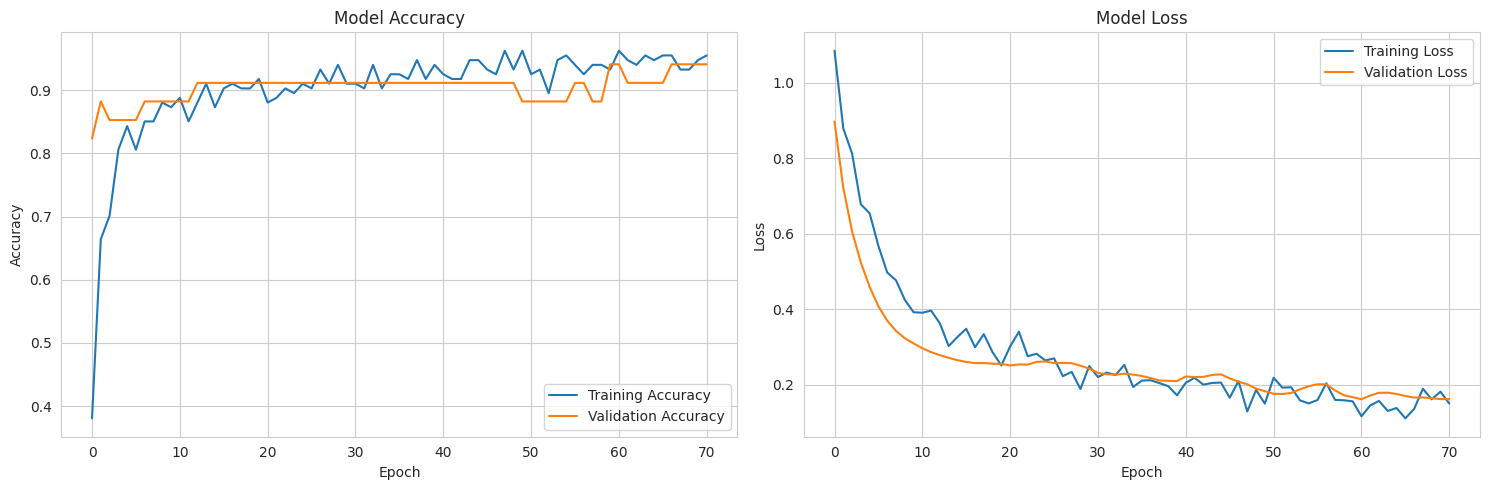

Best validation accuracy: 0.9412
Best validation loss: 0.1617


In [100]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print best validation accuracy
best_val_acc = max(history.history['val_accuracy'])
print(f"Best validation accuracy: {best_val_acc:.4f}")

#Print best validation loss
best_val_loss = min(history.history['val_loss'])
print(f"Best validation loss: {best_val_loss:.4f}")

### **Conclusions for Section 3**
Overall, the model trained efficiently, prevented overfitting and achieved strong validation performance. This suggests the neural network architecture (64→32 units, ReLU, Dropout) is well-suited.

## **Section 4. Hyperparameter Comparison**


### **Hyperparameter Modification**
For this section a hyperparameter modification is made in the dropout rate which was 0.4 for the original model. Therefore, two new models are created:
- **Model A**: Dropout = 0.2 (light regularization)  
- **Model B**: Dropout = 0.5 (strong regularization)

This helps us understand how much regularization is optimal for this small dataset.

In [101]:
tf.random.set_seed(42)

def create_model(dropout_rate):
    model2 = Sequential([
        Dense(64, activation='relu', input_shape=(7,)),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dropout(dropout_rate),
        Dense(3, activation='softmax')
    ])
    model2.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model2
# Model A: Light dropout
model_dropout_02 = create_model(dropout_rate=0.2)
print("Training Model A (Dropout = 0.2)")
history_02 = model_dropout_02.fit(X_train_scaled, y_train,
                                  validation_split=0.2,
                                  epochs=100,
                                  batch_size=16,
                                  callbacks=[early_stopping],
                                  verbose=0)

# Model B: Strong dropout
model_dropout_05 = create_model(dropout_rate=0.5)
print("Training Model B (Dropout = 0.5)")
history_05 = model_dropout_05.fit(X_train_scaled, y_train,
                                  validation_split=0.2,
                                  epochs=100,
                                  batch_size=16,
                                  callbacks=[early_stopping],
                                  verbose=0)

# Extract best val accuracy
best_val_02 = max(history_02.history['val_accuracy'])
best_val_05 = max(history_05.history['val_accuracy'])
best_loss_02 = min(history_02.history['val_loss'])
best_loss_05 = min(history_05.history['val_loss'])
print(f"\nBest validation accuracy — Dropout 0.2: {best_val_02:.4f}")
print(f"Best validation loss — Dropout 0.2: {best_loss_02:.4f}")
print(f"Best validation accuracy — Dropout 0.5: {best_val_05:.4f}")
print(f"Best validation loss — Dropout 0.5: {best_loss_05:.4f}")

Training Model A (Dropout = 0.2)
Training Model B (Dropout = 0.5)

Best validation accuracy — Dropout 0.2: 0.9706
Best validation loss — Dropout 0.2: 0.1335
Best validation accuracy — Dropout 0.5: 0.9118
Best validation loss — Dropout 0.5: 0.1656


### **Models Comparison**
After developing both models, one can see that the light regularization method (dropout = 0.2) is superior than the strong one (dropout = 0.5). The light regularization method has the highest accuracy and smallest loss value which means that ...

The plot below shows that the Light model uses more epochs to improve its metrics, but overall it has better values in accuracy and loss which indicates that this is the best model.

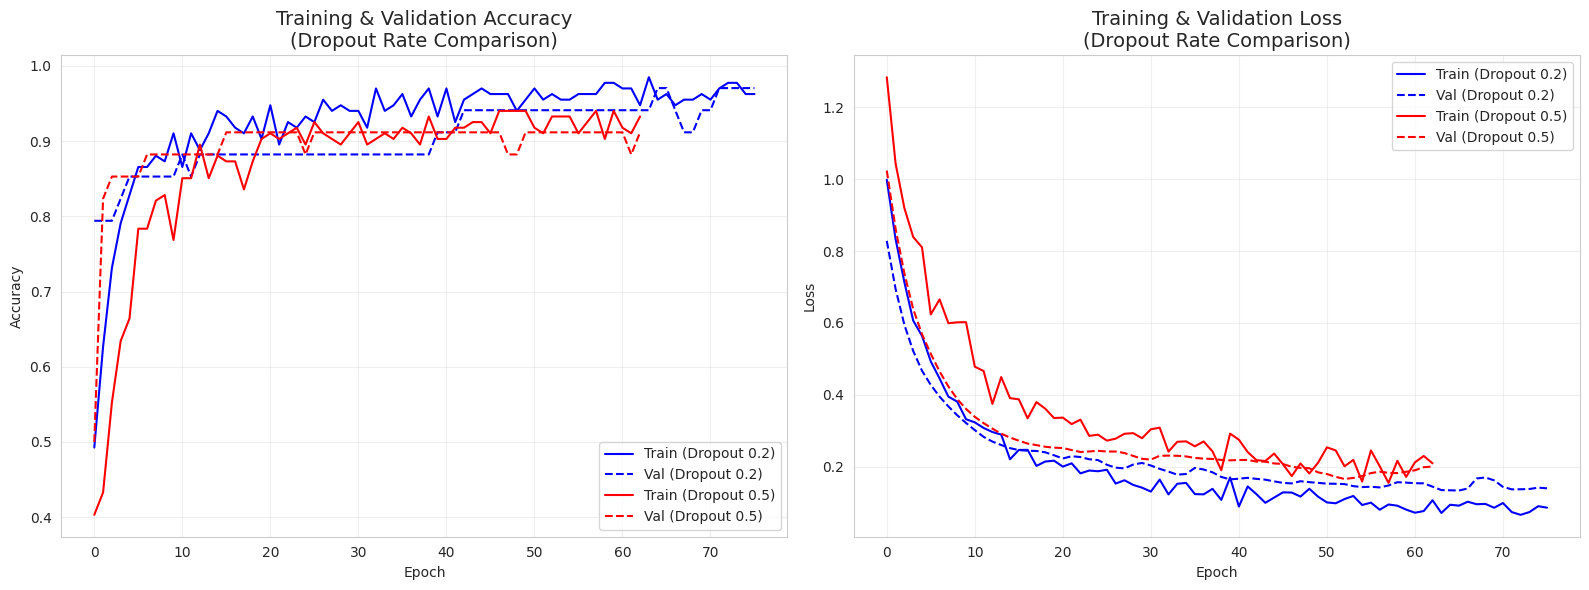

In [102]:
# Plot both models on shared axes (exactly what the assignment wants)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
ax1.plot(history_02.history['accuracy'], label='Train (Dropout 0.2)', color='blue', linestyle='-')
ax1.plot(history_02.history['val_accuracy'], label='Val (Dropout 0.2)', color='blue', linestyle='--')
ax1.plot(history_05.history['accuracy'], label='Train (Dropout 0.5)', color='red', linestyle='-')
ax1.plot(history_05.history['val_accuracy'], label='Val (Dropout 0.5)', color='red', linestyle='--')
ax1.set_title('Training & Validation Accuracy\n(Dropout Rate Comparison)', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history_02.history['loss'], label='Train (Dropout 0.2)', color='blue', linestyle='-')
ax2.plot(history_02.history['val_loss'], label='Val (Dropout 0.2)', color='blue', linestyle='--')
ax2.plot(history_05.history['loss'], label='Train (Dropout 0.5)', color='red', linestyle='-')
ax2.plot(history_05.history['val_loss'], label='Val (Dropout 0.5)', color='red', linestyle='--')
ax2.set_title('Training & Validation Loss\n(Dropout Rate Comparison)', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Conclusions for Section 4**
* Both models give excellent validation accuracy and loss, but the superiority of the light regularization model cannot be denied.
* Considering the validation data in this section, one can say that the 0.2 dropout rate model is even better than the original 0.4 dropout model. However, this needs to be validated in the final section.

## **Section 5. Final Evaluation**

#### Models Comparison on Test Dataset
The final section starts with creating the models using all the training data for ... . Next, the accuracy for the smaller dropout (0.2) is the highest of both models similar to what was seen in the validation part.

Finally, all the evaluation metrics (precision, accuracy, F1-score) are better in the light regularization model (Dropout = 0.2) for all the three classes showing one more time its superiority.

In [105]:
final_model_02 = create_model(dropout_rate=0.2)
final_model_02.fit(X_train_scaled, y_train, epochs=100, batch_size=16, verbose=0)

final_model_05 = create_model(dropout_rate=0.5)
final_model_05.fit(X_train_scaled, y_train, epochs=100, batch_size=16, verbose=0)

# Predictions on test set
y_pred_02 = final_model_02.predict(X_test_scaled).argmax(axis=1)
y_pred_05 = final_model_05.predict(X_test_scaled).argmax(axis=1)

# Accuracy
acc_02 = accuracy_score(y_test, y_pred_02)
acc_05 = accuracy_score(y_test, y_pred_05)

print("="*60)
print("FINAL TEST SET RESULTS")
print("="*60)
print(f"Model with Dropout 0.2 → Test Accuracy: {acc_02:.4f} ({acc_02*100:.2f}%)")
print(f"Model with Dropout 0.5 → Test Accuracy: {acc_05:.4f} ({acc_05*100:.2f}%)")
print(f"\n→ Best model: Dropout = 0.2" if acc_02 >= acc_05 else "\n→ Best model: Dropout = 0.5")

print("\nDetailed metrics for both models:\n")

print("Dropout 0.2")
print(classification_report(y_test, y_pred_02,
                          target_names=['Kama', 'Rosa', 'Canadian']))

print("Dropout 0.5")
print(classification_report(y_test, y_pred_05,
                          target_names=['Kama', 'Rosa', 'Canadian']))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
FINAL TEST SET RESULTS
Model with Dropout 0.2 → Test Accuracy: 0.8810 (88.10%)
Model with Dropout 0.5 → Test Accuracy: 0.8571 (85.71%)

→ Best model: Dropout = 0.2

Detailed metrics for both models:

Dropout 0.2
              precision    recall  f1-score   support

        Kama       1.00      0.64      0.78        14
        Rosa       0.88      1.00      0.93        14
    Canadian       0.82      1.00      0.90        14

    accuracy                           0.88        42
   macro avg       0.90      0.88      0.87        42
weighted avg       0.90      0.88      0.87        42

Dropout 0.5
              precision    recall  f1-score   support

        Kama       1.00      0.57      0.73        14
        Rosa       0.82      1.00      0.90        14
    Canadian       0.82      1.00      0.90        14

    accuracy                           0.86        42
   macro avg       0.88      0.86      0.84    

#### **Confusion Matrix**
Finally, a confusion matrix was made where

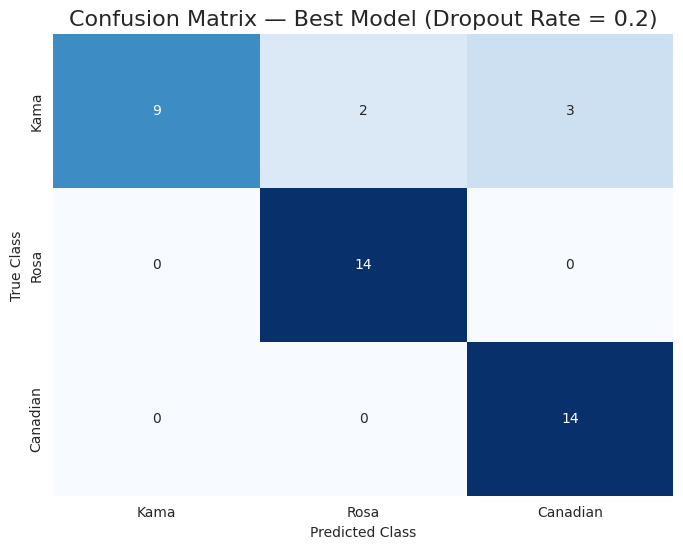

In [107]:
# Confusion Matrix for the Best Model
best_predictions = y_pred_02

plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Kama', 'Rosa', 'Canadian'],
            yticklabels=['Kama', 'Rosa', 'Canadian'], cbar=False)
plt.title('Confusion Matrix — Best Model (Dropout Rate = 0.2)', fontsize=16)
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()